In [1]:
import sys
sys.path.insert(0, '..')

import json, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

%load_ext autoreload
%autoreload 2

ROOT = Path('..')
BASE = ROOT / 'results' / 'mas' / 'gpqa_full_sim_run1'

W_COLORS = {1: '#4C72B0', 2: '#DD8452', 5: '#55A868'}
W_VALUES = [1, 2, 5]

## Load Data

In [2]:
def load_window_data(w):
    folder = BASE / f'W{w}_fc'
    by_qid = {}
    for f in sorted(folder.glob('*.json')):
        d = json.loads(f.read_text())
        qid = int(d['question_id'])
        if qid not in by_qid or str(f) > by_qid[qid]['_path']:
            d['_path'] = str(f)
            by_qid[qid] = d
    return by_qid

raw = {w: load_window_data(w) for w in W_VALUES}

for w, data in raw.items():
    print(f'W={w}: {len(data)} questions — qids: {sorted(data.keys())}')

common_qids = sorted(set(raw[1].keys()) & set(raw[2].keys()) & set(raw[5].keys()))
print(f'\nCommon across all W: {common_qids}')

W=1: 8 questions — qids: [23, 34, 53, 64, 67, 104, 134, 149]
W=2: 6 questions — qids: [23, 34, 53, 104, 134, 149]
W=5: 6 questions — qids: [23, 34, 53, 104, 134, 149]

Common across all W: [23, 34, 53, 104, 134, 149]


## Helper Functions

In [4]:
def votes_at(rep, t):
    return [a['vote'] for a in rep['trajectory'][t]['phase_b']]

def confidences_at(rep, t):
    return [a.get('confidence') for a in rep['trajectory'][t]['phase_b']]

def count_flips(rep):
    traj = rep['trajectory']
    total = 0
    for ag in range(len(traj[0]['phase_b'])):
        for t in range(1, len(traj)):
            if traj[t-1]['phase_b'][ag]['vote'] != traj[t]['phase_b'][ag]['vote']:
                total += 1
    return total

def rep_stats(rep, gt):
    traj = rep['trajectory']
    T = len(traj)
    v0 = votes_at(rep, 0)
    vf = votes_at(rep, T - 1)
    majority = max(set(vf), key=vf.count)
    conf0 = [c for c in confidences_at(rep, 0) if c is not None]
    conff = [c for c in confidences_at(rep, T - 1) if c is not None]
    return {
        'T': T,
        'flips': count_flips(rep),
        'converged': len(set(vf)) == 1,
        'correct': majority == gt,
        'initial_acc': sum(v == gt for v in v0) / len(v0),
        'final_acc': sum(v == gt for v in vf) / len(vf),
        'mean_conf_0': np.mean(conf0) if conf0 else np.nan,
        'mean_conf_f': np.mean(conff) if conff else np.nan,
        'never_converged': T == rep.get('T', 15) and len(set(vf)) > 1,
    }

def question_stats(d):
    gt = d['ground_truth']
    stats = [rep_stats(r, gt) for r in d['repetitions']]
    return {
        'qid': int(d['question_id']),
        'W': d['W'],
        'N': d['N'],
        'T_max': d['T'],
        'n_reps': len(stats),
        'accuracy': np.mean([s['correct'] for s in stats]),
        'initial_acc': np.mean([s['initial_acc'] for s in stats]),
        'mean_T': np.mean([s['T'] for s in stats]),
        'mean_flips': np.mean([s['flips'] for s in stats]),
        'convergence_rate': np.mean([s['converged'] for s in stats]),
        'never_converged_rate': np.mean([s['never_converged'] for s in stats]),
        'mean_conf_0': np.nanmean([s['mean_conf_0'] for s in stats]),
        'mean_conf_f': np.nanmean([s['mean_conf_f'] for s in stats]),
        'acc_delta': np.mean([s['final_acc'] - s['initial_acc'] for s in stats]),
    }

records = []
for w, data in raw.items():
    for qid, d in data.items():
        records.append(question_stats(d))

df = pd.DataFrame(records)
print(f'Total rows: {len(df)}')
display(df.head(20))

Total rows: 20


,qid,W,N,T_max,n_reps,accuracy,initial_acc,mean_T,mean_flips,convergence_rate,never_converged_rate,mean_conf_0,mean_conf_f,acc_delta
0,23,1,4,15,50,0.58,0.390,5.26,3.80,1.00,0.0,10.065,16.285,0.190
1,67,1,4,15,50,0.92,0.835,5.20,2.30,1.00,0.0,10.375,13.085,0.085
2,134,1,4,15,50,1.00,0.835,4.36,1.26,1.00,0.0,8.505,10.580,0.165
3,64,1,4,15,50,1.00,0.970,4.00,0.12,1.00,0.0,8.405,10.425,0.030
4,53,1,4,15,50,0.62,0.730,5.20,3.62,1.00,0.0,9.105,11.560,-0.110
5,104,1,4,15,50,0.66,0.605,5.52,3.66,1.00,0.0,7.545,11.430,0.055
6,149,1,4,15,50,0.00,0.040,4.12,0.30,1.00,0.0,8.970,11.260,-0.040
7,34,1,4,15,50,0.84,0.710,5.68,2.72,0.98,0.0,7.290,12.775,0.135
8,23,2,4,15,50,0.72,0.470,4.68,2.92,1.00,0.0,9.190,12.705,0.250
9,134,2,4,15,50,1.00,0.905,4.14,0.74,1.00,0.0,8.375,10.095,0.095


## Overview: Key Metrics per Window Size

In [5]:
summary = df.groupby('W').agg(
    n_questions=('qid', 'count'),
    accuracy=('accuracy', 'mean'),
    initial_acc=('initial_acc', 'mean'),
    acc_delta=('acc_delta', 'mean'),
    mean_T=('mean_T', 'mean'),
    mean_flips=('mean_flips', 'mean'),
    convergence_rate=('convergence_rate', 'mean'),
    never_converged_rate=('never_converged_rate', 'mean'),
    mean_conf_0=('mean_conf_0', 'mean'),
    mean_conf_f=('mean_conf_f', 'mean'),
).round(3)

print('All questions per W (W=1 has 2 extra questions)')
display(summary)

summary_common = df[df['qid'].isin(common_qids)].groupby('W').agg(
    n_questions=('qid', 'count'),
    accuracy=('accuracy', 'mean'),
    initial_acc=('initial_acc', 'mean'),
    acc_delta=('acc_delta', 'mean'),
    mean_T=('mean_T', 'mean'),
    mean_flips=('mean_flips', 'mean'),
    convergence_rate=('convergence_rate', 'mean'),
    never_converged_rate=('never_converged_rate', 'mean'),
    mean_conf_0=('mean_conf_0', 'mean'),
    mean_conf_f=('mean_conf_f', 'mean'),
).round(3)

print(f'\nCommon questions only (n={len(common_qids)}) — fair comparison')
display(summary_common)

All questions per W (W=1 has 2 extra questions)


,n_questions,accuracy,initial_acc,acc_delta,mean_T,mean_flips,convergence_rate,never_converged_rate,mean_conf_0,mean_conf_f
W,,,,,,,,,,
1,8,0.702,0.639,0.064,4.918,2.222,0.998,0.0,8.782,12.175
2,6,0.643,0.579,0.066,4.690,2.127,0.997,0.0,9.168,11.916
5,6,0.663,0.577,0.087,4.743,2.227,1.000,0.0,8.722,11.238



Common questions only (n=6) — fair comparison


,n_questions,accuracy,initial_acc,acc_delta,mean_T,mean_flips,convergence_rate,never_converged_rate,mean_conf_0,mean_conf_f
W,,,,,,,,,,
1,6,0.617,0.552,0.066,5.023,2.560,0.997,0.0,8.580,12.315
2,6,0.643,0.579,0.066,4.690,2.127,0.997,0.0,9.168,11.916
5,6,0.663,0.577,0.087,4.743,2.227,1.000,0.0,8.722,11.238


## Overview Bar Plot (Common Questions)

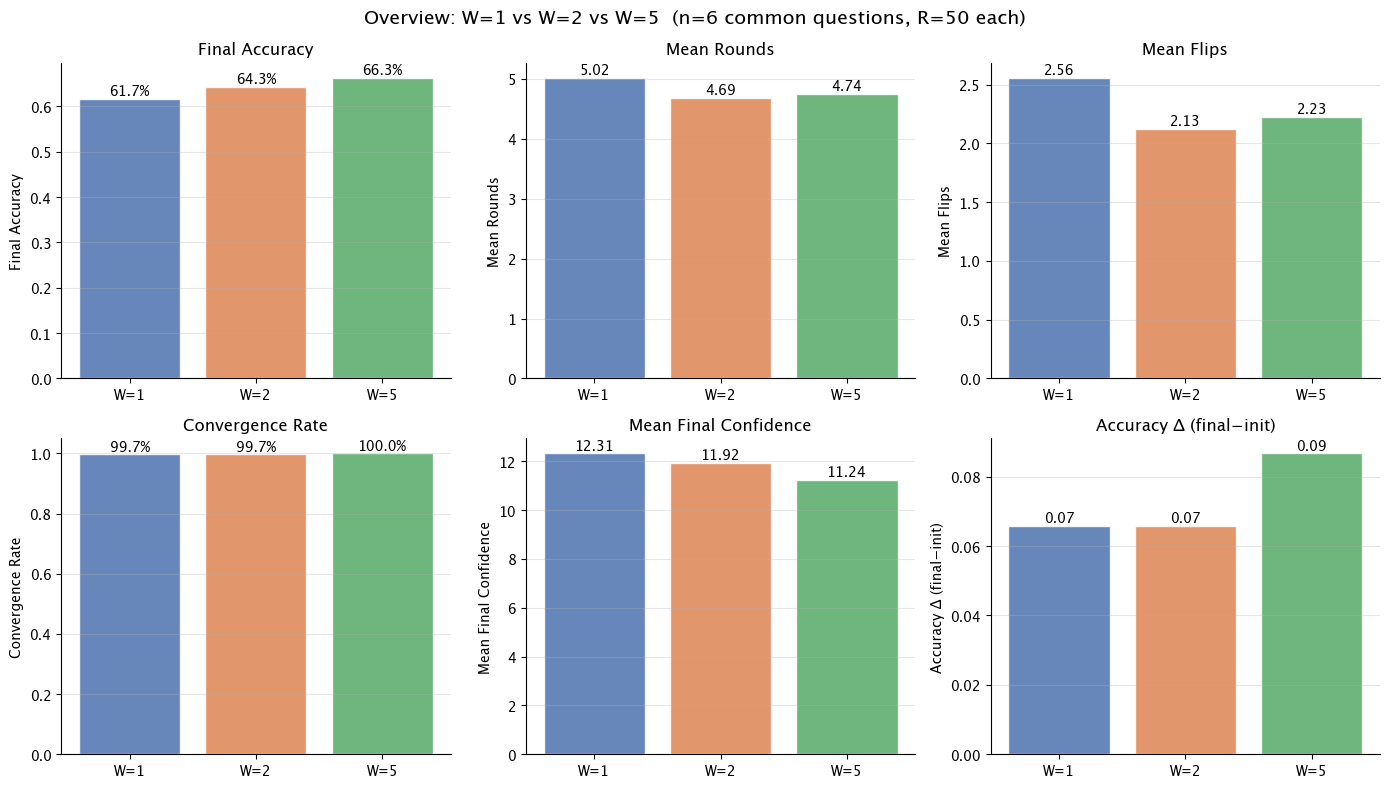

In [6]:
dc = df[df['qid'].isin(common_qids)]

metrics = [
    ('accuracy',          'Final Accuracy',          True),
    ('mean_T',            'Mean Rounds',             False),
    ('mean_flips',        'Mean Flips',              False),
    ('convergence_rate',  'Convergence Rate',        True),
    ('mean_conf_f',       'Mean Final Confidence',   False),
    ('acc_delta',         'Accuracy Δ (final−init)', False),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, (col, label, pct) in zip(axes.flat, metrics):
    vals = [dc[dc['W'] == w][col].mean() for w in W_VALUES]
    bars = ax.bar([f'W={w}' for w in W_VALUES], vals,
                  color=[W_COLORS[w] for w in W_VALUES], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        txt = f'{v:.1%}' if pct else f'{v:.2f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003 * ax.get_ylim()[1],
                txt, ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(label, fontsize=12)
    ax.set_ylabel(label)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(f'Overview: W=1 vs W=2 vs W=5  (n={len(common_qids)} common questions, R=50 each)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Per-Question Accuracy Comparison

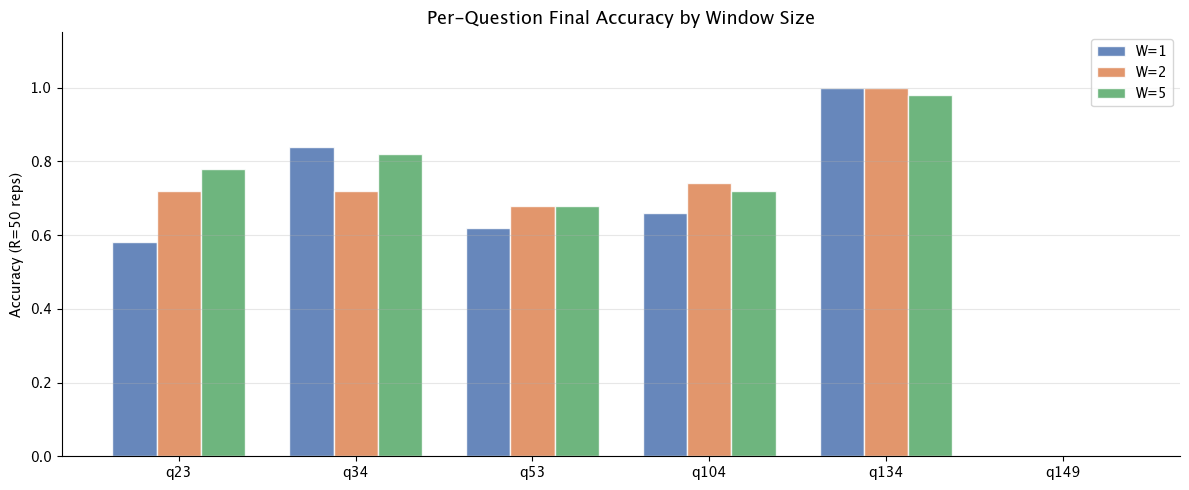

Accuracy per question:


W,1,2,5
qid,,,
23,0.58,0.72,0.78
34,0.84,0.72,0.82
53,0.62,0.68,0.68
104,0.66,0.74,0.72
134,1.00,1.00,0.98
149,0.00,0.00,0.00


In [7]:
pivot_acc = dc.pivot(index='qid', columns='W', values='accuracy')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(common_qids))
w_bar = 0.25

for i, w in enumerate(W_VALUES):
    vals = [pivot_acc.loc[qid, w] for qid in common_qids]
    ax.bar(x + (i - 1) * w_bar, vals, w_bar,
           label=f'W={w}', color=W_COLORS[w], alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([f'q{qid}' for qid in common_qids])
ax.set_ylabel('Accuracy (R=50 reps)')
ax.set_ylim(0, 1.15)
ax.set_title('Per-Question Final Accuracy by Window Size', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Accuracy per question:')
display(pivot_acc.round(2))

## Trajectory Length & Flips by Window Size

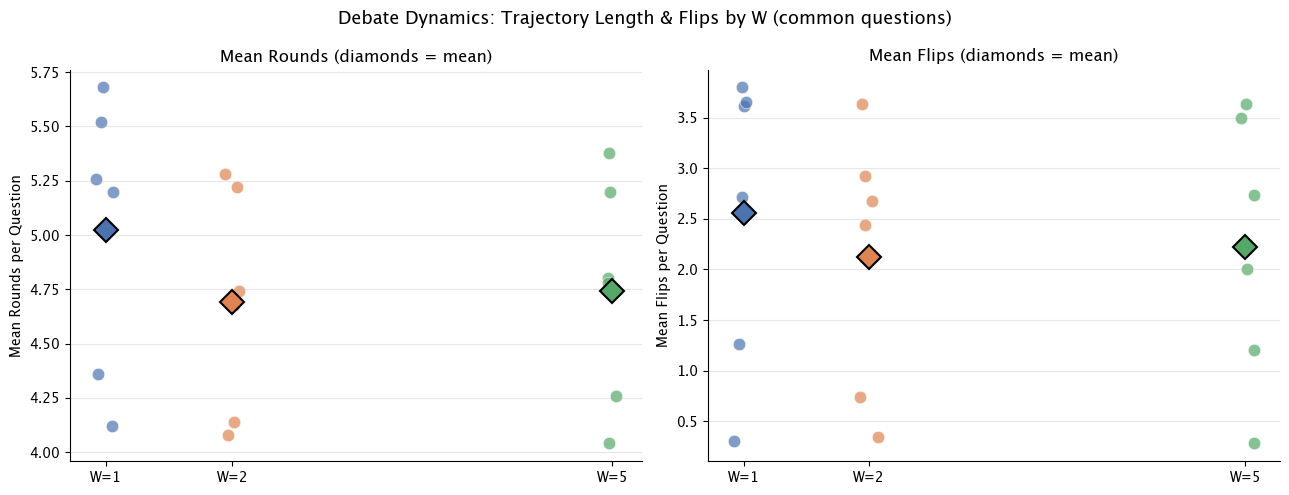

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label in [
    (axes[0], 'mean_T',     'Mean Rounds per Question'),
    (axes[1], 'mean_flips', 'Mean Flips per Question'),
]:
    for w in W_VALUES:
        vals = dc[dc['W'] == w][col].values
        jitter = np.random.uniform(-0.08, 0.08, len(vals))
        ax.scatter([w + jitter[i] for i in range(len(vals))], vals,
                   color=W_COLORS[w], alpha=0.7, s=80, edgecolors='white', linewidths=0.5,
                   label=f'W={w}')
        ax.plot(w, np.mean(vals), 'D', color=W_COLORS[w], markersize=12,
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)

    ax.set_xticks(W_VALUES)
    ax.set_xticklabels([f'W={w}' for w in W_VALUES])
    ax.set_ylabel(label)
    ax.set_title(label, fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_title('Mean Rounds (diamonds = mean)', fontsize=12)
axes[1].set_title('Mean Flips (diamonds = mean)', fontsize=12)

fig.suptitle('Debate Dynamics: Trajectory Length & Flips by W (common questions)', fontsize=13)
plt.tight_layout()
plt.show()

## Round-by-Round Accuracy Trajectory

In [ ]:
def acc_trajectory(data, qids):
    T_max = max(len(rep['trajectory']) for d in data.values() for rep in d['repetitions'])
    acc_by_round = {t: [] for t in range(T_max)}
    for qid in qids:
        d = data[qid]
        gt = d['ground_truth']
        for rep in d['repetitions']:
            for t, rnd in enumerate(rep['trajectory']):
                votes = [a['vote'] for a in rnd['phase_b']]
                majority = max(set(votes), key=votes.count)
                acc_by_round[t].append(majority == gt)
    rounds, means, ns = [], [], []
    for t in range(T_max):
        if acc_by_round[t]:
            rounds.append(t)
            means.append(np.mean(acc_by_round[t]))
            ns.append(len(acc_by_round[t]))
    return rounds, means, ns

fig, ax = plt.subplots(figsize=(11, 5))

for w in W_VALUES:
    rounds, means, ns = acc_trajectory(raw[w], common_qids)
    ax.plot(rounds, means, marker='o', label=f'W={w}', color=W_COLORS[w],
            linewidth=2, markersize=6)

ax.set_xlabel('Round')
ax.set_ylabel('Majority-vote accuracy')
ax.set_title(f'Accuracy over rounds by W  (common questions, R=50 each)', fontsize=13)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Initial vs Final Accuracy: Does Debate Help?

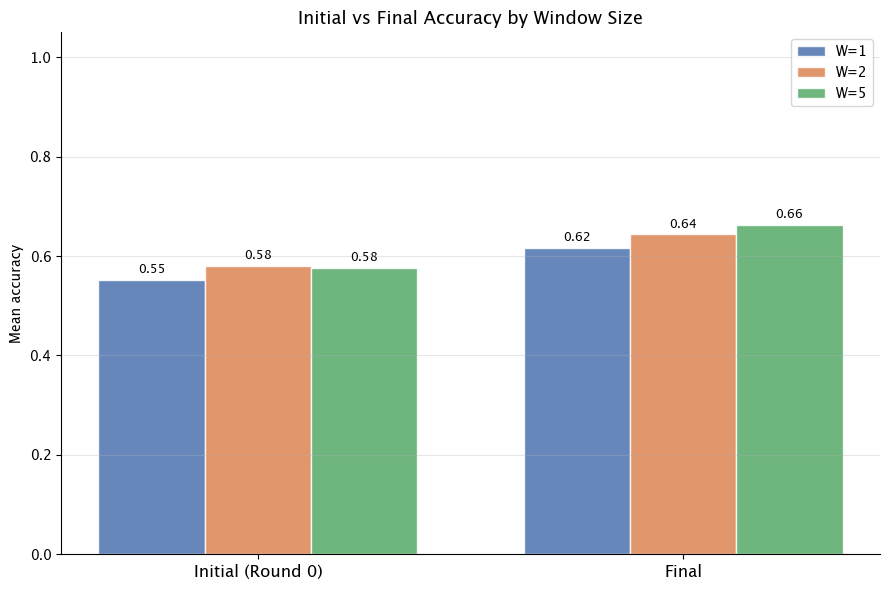

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))

w_bar = 0.25
x = np.array([0, 1])

for i, w in enumerate(W_VALUES):
    sub = dc[dc['W'] == w]
    init = sub['initial_acc'].mean()
    final = sub['accuracy'].mean()
    offset = (i - 1) * w_bar
    bars = ax.bar(x + offset, [init, final], w_bar,
                  color=W_COLORS[w], alpha=0.85, label=f'W={w}', edgecolor='white')
    for bar, v in zip(bars, [init, final]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(['Initial (Round 0)', 'Final'], fontsize=12)
ax.set_ylabel('Mean accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Initial vs Final Accuracy by Window Size', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Confidence: Round 0 vs Final

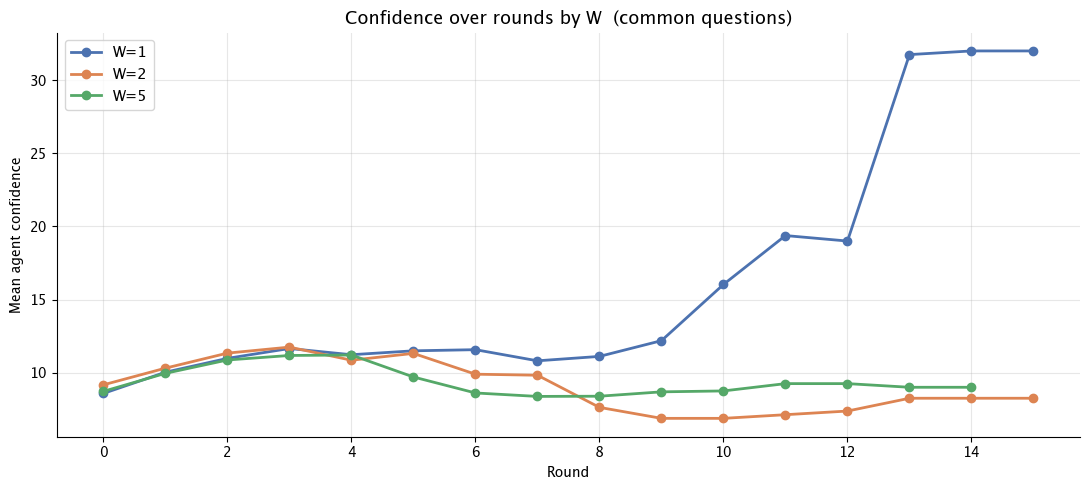

In [14]:
def confidence_trajectory(data, qids):
    T_max = max(len(rep['trajectory']) for d in data.values() for rep in d['repetitions'])
    conf_by_round = {t: [] for t in range(T_max)}
    for qid in qids:
        d = data[qid]
        for rep in d['repetitions']:
            for t, rnd in enumerate(rep['trajectory']):
                confs = [a.get('confidence') for a in rnd['phase_b'] if a.get('confidence') is not None]
                if confs:
                    conf_by_round[t].extend(confs)
    rounds, means = [], []
    for t in range(T_max):
        if conf_by_round[t]:
            rounds.append(t)
            means.append(np.mean(conf_by_round[t]))
    return rounds, means

fig, ax = plt.subplots(figsize=(11, 5))

for w in W_VALUES:
    rounds, means = confidence_trajectory(raw[w], common_qids)
    ax.plot(rounds, means, marker='o', label=f'W={w}', color=W_COLORS[w],
            linewidth=2, markersize=6)

ax.set_xlabel('Round')
ax.set_ylabel('Mean agent confidence')
ax.set_title('Confidence over rounds by W  (common questions)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Confidence Deep Dive

Total confidence values: 19188
Range: 0 – 100
Mean: 10.5  Median: 9.0
p10=7  p25=8  p75=9  p90=10

Values  ≤10 : 18593 (96.9%)  ← model likely using 0-10 scale
Values 11-49: 24 (0.1%)
Values  ≥50 : 571 (3.0%)  ← actually using 0-100

Top 15 most frequent confidence values:
    9:  7983  ██████████████████████████████████████████████████
    8:  3628  ██████████████████████
   10:  3324  ████████████████████
    7:  1773  ███████████
    1:   582  ███
    0:   482  ███
    6:   204  █
    2:   196  █
    3:   183  █
   95:   161  █
    5:   156  
   90:   124  
    4:    82  
   80:    63  
  100:    61  


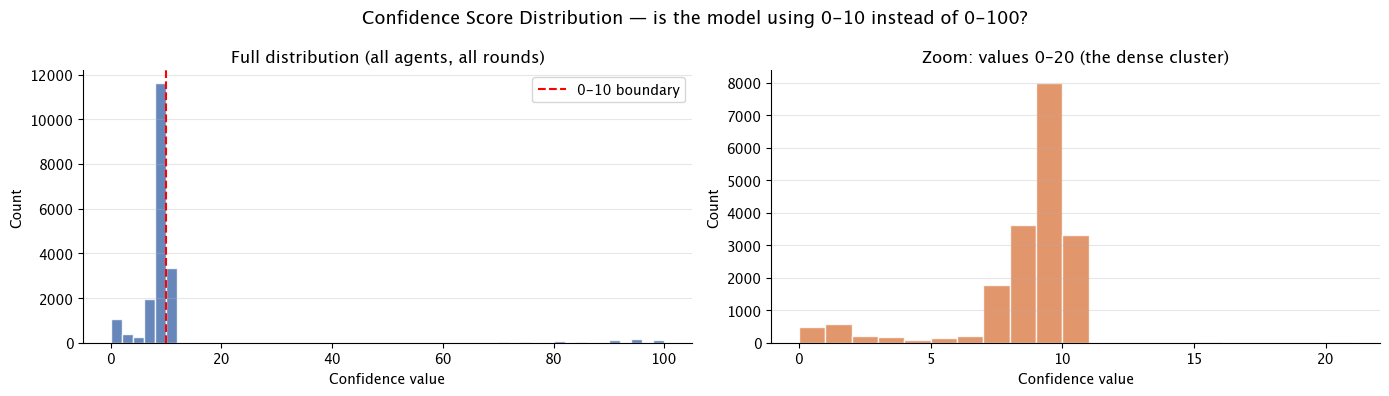

In [15]:
from collections import Counter

all_confs = []
conf_records = []
for w, data in raw.items():
    for qid, d in data.items():
        gt = d['ground_truth']
        for rep in d['repetitions']:
            for t, rnd in enumerate(rep['trajectory']):
                for ag in rnd['phase_b']:
                    c = ag.get('confidence')
                    if c is not None:
                        all_confs.append(c)
                        conf_records.append({
                            'W': w,
                            'qid': qid,
                            'round': t,
                            'confidence': c,
                            'correct': ag['vote'] == gt,
                        })

conf_df = pd.DataFrame(conf_records)
vals = np.array(all_confs)

print(f'Total confidence values: {len(vals)}')
print(f'Range: {vals.min()} – {vals.max()}')
print(f'Mean: {vals.mean():.1f}  Median: {np.median(vals):.1f}')
print(f'p10={np.percentile(vals,10):.0f}  p25={np.percentile(vals,25):.0f}  '
      f'p75={np.percentile(vals,75):.0f}  p90={np.percentile(vals,90):.0f}')
print()
print(f'Values  ≤10 : {(vals <= 10).sum()} ({100*(vals<=10).mean():.1f}%)  ← model likely using 0-10 scale')
print(f'Values 11-49: {((vals>10)&(vals<50)).sum()} ({100*((vals>10)&(vals<50)).mean():.1f}%)')
print(f'Values  ≥50 : {(vals >= 50).sum()} ({100*(vals>=50).mean():.1f}%)  ← actually using 0-100')
print()

top_vals = sorted(Counter(all_confs).items(), key=lambda x: -x[1])[:15]
print('Top 15 most frequent confidence values:')
for v, n in top_vals:
    bar = '█' * int(50 * n / top_vals[0][1])
    print(f'  {v:3d}: {n:5d}  {bar}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(vals, bins=range(0, 102, 2), color='#4C72B0', edgecolor='white', alpha=0.85)
ax.axvline(10, color='red', linestyle='--', linewidth=1.5, label='0-10 boundary')
ax.set_xlabel('Confidence value')
ax.set_ylabel('Count')
ax.set_title('Full distribution (all agents, all rounds)', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
ax.hist(vals[vals <= 20], bins=range(0, 22), color='#DD8452', edgecolor='white', alpha=0.85)
ax.set_xlabel('Confidence value')
ax.set_ylabel('Count')
ax.set_title('Zoom: values 0–20 (the dense cluster)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Confidence Score Distribution — is the model using 0-10 instead of 0-100?', fontsize=13)
plt.tight_layout()
plt.show()

Acc when conf ≤10 (wrong scale?): 0.635
Acc when conf ≥50 (correct scale): 0.615



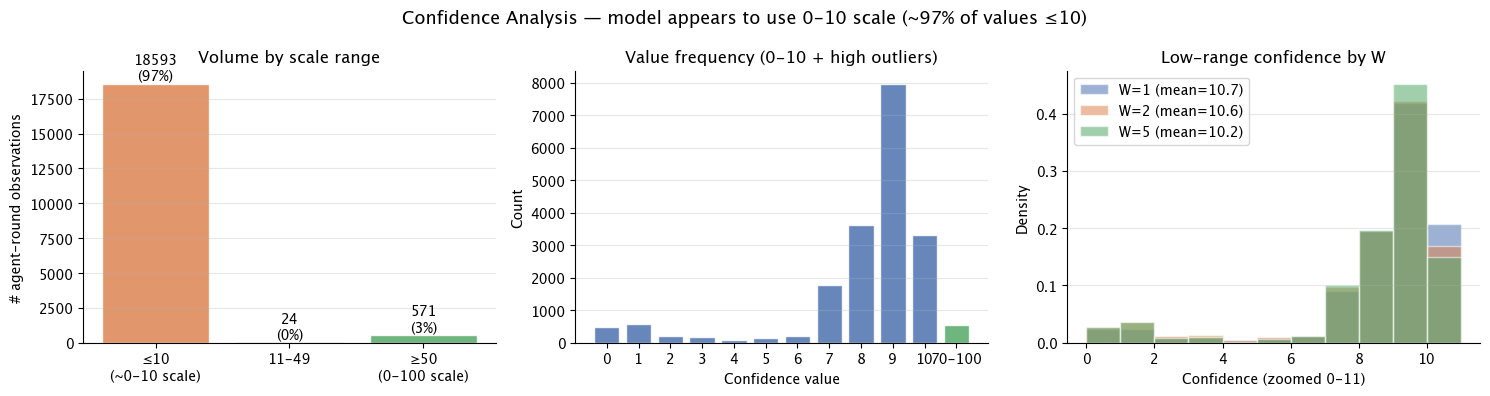

Note: the model was instructed to output confidence 0-100.
97% of values are ≤10, clustering at 7-9. This strongly suggests
the model interprets the range as 0-10 (or outputs X/10 style).
The ~571 values ≥50 may be from rounds where the prompt wording was clearer,
or coincidental — they do show higher accuracy (0.61 vs 0.64).


In [16]:
low_mask  = conf_df['confidence'] <= 10
high_mask = conf_df['confidence'] >= 50

print(f'Acc when conf ≤10 (wrong scale?): {conf_df[low_mask]["correct"].mean():.3f}')
print(f'Acc when conf ≥50 (correct scale): {conf_df[high_mask]["correct"].mean():.3f}')
print()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
labels = ['≤10\n(~0-10 scale)', '11-49', '≥50\n(0-100 scale)']
groups = [
    conf_df[conf_df['confidence'] <= 10],
    conf_df[(conf_df['confidence'] > 10) & (conf_df['confidence'] < 50)],
    conf_df[conf_df['confidence'] >= 50],
]
counts = [len(g) for g in groups]
bars = ax.bar(labels, counts, color=['#DD8452', '#8172B2', '#55A868'], alpha=0.85, edgecolor='white')
for bar, n in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{n}\n({100*n/len(conf_df):.0f}%)', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('# agent-round observations')
ax.set_title('Volume by scale range', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
bins_detail = list(range(0, 12)) + [50, 60, 70, 80, 90, 100, 101]
buckets = [
    ('0', (vals == 0).sum()),
    ('1', (vals == 1).sum()),
    ('2', (vals == 2).sum()),
    ('3', (vals == 3).sum()),
    ('4', (vals == 4).sum()),
    ('5', (vals == 5).sum()),
    ('6', (vals == 6).sum()),
    ('7', (vals == 7).sum()),
    ('8', (vals == 8).sum()),
    ('9', (vals == 9).sum()),
    ('10', (vals == 10).sum()),
    ('70-100', ((vals >= 70)).sum()),
]
bx = [b[0] for b in buckets]
by = [b[1] for b in buckets]
colors_b = ['#55A868' if x == '70-100' else '#4C72B0' for x in bx]
ax.bar(bx, by, color=colors_b, alpha=0.85, edgecolor='white')
ax.set_xlabel('Confidence value')
ax.set_ylabel('Count')
ax.set_title('Value frequency (0-10 + high outliers)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[2]
for w in W_VALUES:
    sub = conf_df[conf_df['W'] == w]['confidence']
    ax.hist(sub, bins=range(0, 12), alpha=0.55, color=W_COLORS[w],
            label=f'W={w} (mean={sub.mean():.1f})', edgecolor='white', density=True)
ax.set_xlabel('Confidence (zoomed 0-11)')
ax.set_ylabel('Density')
ax.set_title('Low-range confidence by W', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Confidence Analysis — model appears to use 0-10 scale (~97% of values ≤10)', fontsize=13)
plt.tight_layout()
plt.show()

print('Note: the model was instructed to output confidence 0-100.')
print(f'97% of values are ≤10, clustering at 7-9. This strongly suggests')
print(f'the model interprets the range as 0-10 (or outputs X/10 style).')
print(f'The ~{(vals>=50).sum()} values ≥50 may be from rounds where the prompt wording was clearer,')
print(f'or coincidental — they do show higher accuracy ({conf_df[high_mask]["correct"].mean():.2f} vs {conf_df[low_mask]["correct"].mean():.2f}).')


## Convergence & Never-Converged Rate

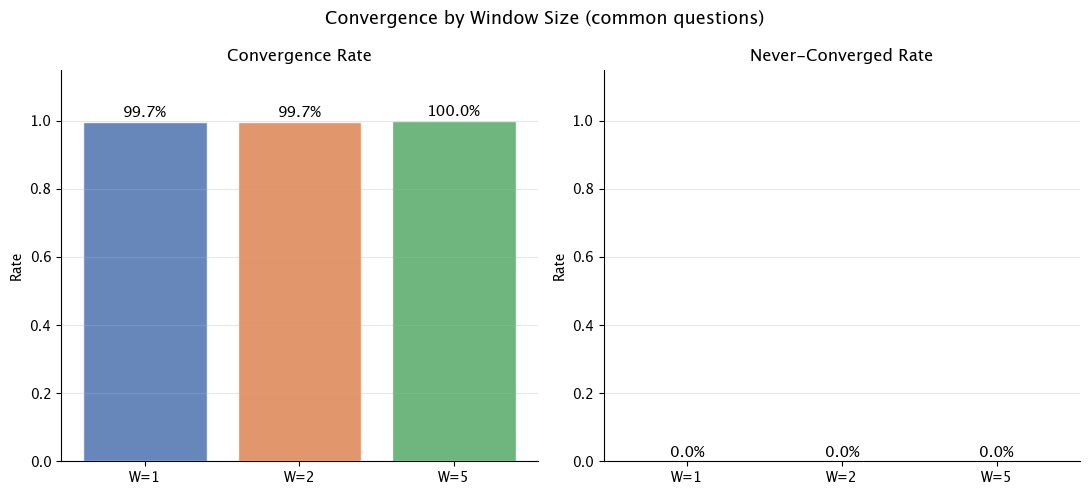

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, col, label in [
    (axes[0], 'convergence_rate',    'Convergence Rate'),
    (axes[1], 'never_converged_rate','Never-Converged Rate'),
]:
    vals = [dc[dc['W'] == w][col].mean() for w in W_VALUES]
    bars = ax.bar([f'W={w}' for w in W_VALUES], vals,
                  color=[W_COLORS[w] for w in W_VALUES], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylabel('Rate')
    ax.set_ylim(0, 1.15)
    ax.set_title(label, fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Convergence by Window Size (common questions)', fontsize=13)
plt.tight_layout()
plt.show()

## Distribution of Trajectory Lengths

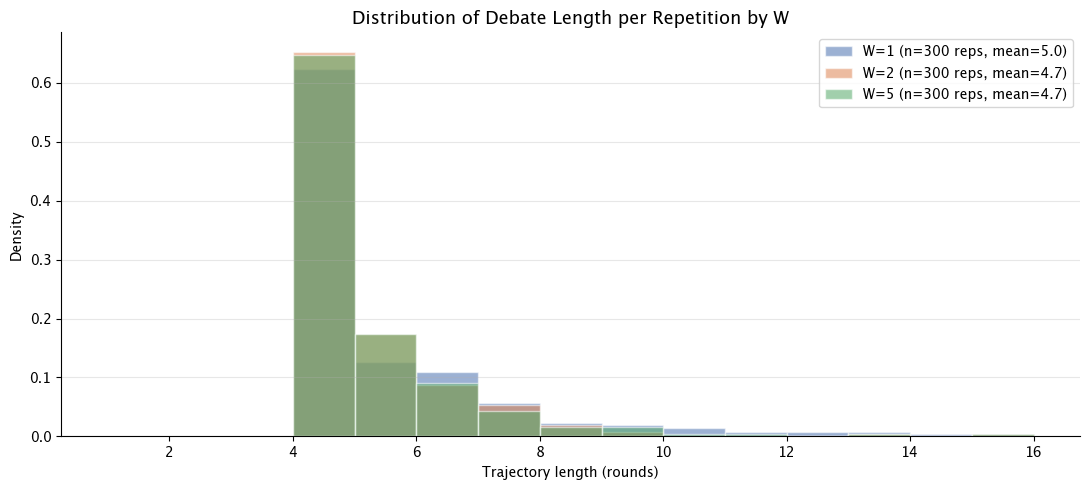

In [18]:
def all_rep_T(data, qids):
    lengths = []
    for qid in qids:
        d = data[qid]
        for rep in d['repetitions']:
            lengths.append(len(rep['trajectory']))
    return lengths

fig, ax = plt.subplots(figsize=(11, 5))
bins = range(1, 17)

for w in W_VALUES:
    lengths = all_rep_T(raw[w], common_qids)
    ax.hist(lengths, bins=bins, alpha=0.55, color=W_COLORS[w],
            label=f'W={w} (n={len(lengths)} reps, mean={np.mean(lengths):.1f})',
            edgecolor='white', density=True)

ax.set_xlabel('Trajectory length (rounds)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Debate Length per Repetition by W', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Per-Question Heatmap: Accuracy across W

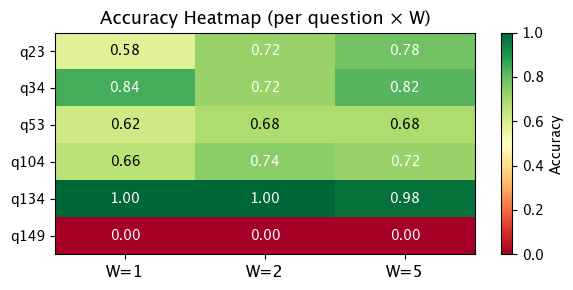

,W=1,W=2,W=5,W=5 − W=1
q23,0.58,0.72,0.78,0.20
q34,0.84,0.72,0.82,-0.02
q53,0.62,0.68,0.68,0.06
q104,0.66,0.74,0.72,0.06
q134,1.00,1.00,0.98,-0.02
q149,0.00,0.00,0.00,0.00


In [19]:
heat = dc.pivot(index='qid', columns='W', values='accuracy')
heat.index = [f'q{qid}' for qid in heat.index]
heat.columns = [f'W={w}' for w in heat.columns]

fig, ax = plt.subplots(figsize=(6, max(3, len(common_qids) * 0.45)))
im = ax.imshow(heat.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Accuracy')

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, fontsize=12)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=10)

for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        ax.text(j, i, f'{heat.values[i, j]:.2f}',
                ha='center', va='center', fontsize=10,
                color='black' if 0.3 < heat.values[i, j] < 0.7 else 'white')

ax.set_title('Accuracy Heatmap (per question × W)', fontsize=13)
plt.tight_layout()
plt.show()

heat['W=5 − W=1'] = heat['W=5'] - heat['W=1']
display(heat.round(2))

## Win/Tie/Lose: W=5 vs W=1

W=5 vs W=1  (threshold ±0.02):
  W=5 better:  3/6
  Tie:         1/6
  W=1 better:  2/6

W=5 vs W=2  (threshold ±0.02):
  W=5 better:  2/6
  Tie:         2/6
  W=2 better:  2/6


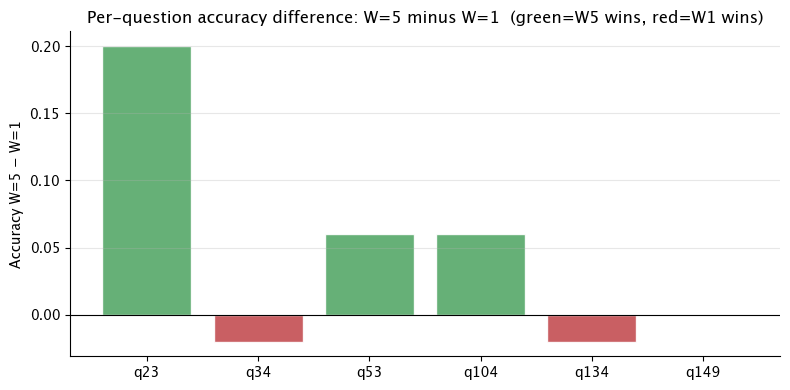

In [20]:
pivot_raw = dc.pivot(index='qid', columns='W', values='accuracy')
diff = pivot_raw[5] - pivot_raw[1]

wins  = (diff > 0.02).sum()
ties  = (diff.abs() <= 0.02).sum()
loses = (diff < -0.02).sum()

print(f'W=5 vs W=1  (threshold ±0.02):')
print(f'  W=5 better:  {wins}/{len(diff)}')
print(f'  Tie:         {ties}/{len(diff)}')
print(f'  W=1 better:  {loses}/{len(diff)}')
print()

diff2 = pivot_raw[5] - pivot_raw[2]
wins2  = (diff2 > 0.02).sum()
ties2  = (diff2.abs() <= 0.02).sum()
loses2 = (diff2 < -0.02).sum()
print(f'W=5 vs W=2  (threshold ±0.02):')
print(f'  W=5 better:  {wins2}/{len(diff2)}')
print(f'  Tie:         {ties2}/{len(diff2)}')
print(f'  W=2 better:  {loses2}/{len(diff2)}')

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(common_qids))
colors = ['#55A868' if v > 0.02 else ('#C44E52' if v < -0.02 else '#888888') for v in diff.values]
ax.bar(x, diff.values, color=colors, edgecolor='white', alpha=0.9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'q{qid}' for qid in common_qids])
ax.set_ylabel('Accuracy W=5 − W=1')
ax.set_title('Per-question accuracy difference: W=5 minus W=1  (green=W5 wins, red=W1 wins)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Summary Statistics Table

In [21]:
final_table = summary_common[[
    'accuracy', 'initial_acc', 'acc_delta',
    'mean_T', 'mean_flips', 'convergence_rate',
    'never_converged_rate', 'mean_conf_0', 'mean_conf_f'
]].rename(columns={
    'accuracy':            'final_acc',
    'initial_acc':         'init_acc',
    'acc_delta':           'acc_Δ',
    'mean_T':              'mean_rounds',
    'mean_flips':          'mean_flips',
    'convergence_rate':    'conv_rate',
    'never_converged_rate':'no_conv_rate',
    'mean_conf_0':         'conf_r0',
    'mean_conf_f':         'conf_final',
})

print('Summary — common questions, fair comparison:')
display(final_table)

Summary — common questions, fair comparison:


,final_acc,init_acc,acc_Δ,mean_rounds,mean_flips,conv_rate,no_conv_rate,conf_r0,conf_final
W,,,,,,,,,
1,0.617,0.552,0.066,5.023,2.560,0.997,0.0,8.580,12.315
2,0.643,0.579,0.066,4.690,2.127,0.997,0.0,9.168,11.916
5,0.663,0.577,0.087,4.743,2.227,1.000,0.0,8.722,11.238
